# **IMPORT LIBRARY**

Tahap ini dilakukan untuk mengimpor berbagai library yang akan diperlukan untuk mendukung proses pengolahan, analisis serta visualisasi data.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set(style='whitegrid')

# **LOAD DATA**

Tahap ini dilakukan untuk memuat *(load)* dataset yang akan digunakan dalam proses analisis.

In [ ]:
transaction_clean = pd.read_csv("../data/processed/transactions/transactions_clean.csv")

In [4]:
# Cek isi data dalam 5 baris awal
transaction_clean.head()

,Transaction_ID,Date,Product_Name,Category,Units_Sold,Unit_Price,Revenue,Stock_In,Stock_Out,Stock_End
0,TRX000001,2023-01-01,ABC Kecap Asin 620ml,Groceries,47,18000.0,846000.0,627,47,580
1,TRX000002,2023-01-01,ABC Kecap Manis 620ml,Groceries,13,18000.0,234000.0,486,13,473
2,TRX000003,2023-01-01,ABC Sari Kacang Hijau 250ml,Drinks,2,4000.0,8000.0,673,2,671
3,TRX000004,2023-01-01,Aqua 600ml,Drinks,7,4000.0,28000.0,690,7,683
4,TRX000005,2023-01-01,Bango Kecap Manis 189gr,Groceries,19,18000.0,342000.0,674,19,655


**Insight:**

- Dataset berhasil dimuat ke lingkungan kerja dan terbaca dalam bentuk *dataframe*, sehingga siap digunakan pada proses analisis selanjutnya.
- Hasil pemeriksaan awal menggunakan `transaction_clean.head()` menunjukkan bahwa data berhasil ditampilkan dan setiap kolom dapat terbaca dengan baik, sehingga dapat digunakan untuk proses eksplorasi dan analisis selanjutnya.


# **DATA UNDERSTANDING**

Tahap ini dilakukan untuk memahami karakteristik dataset sebelum proses analisis lebih lanjut. Pemeriksaan dilakukan terhadap jumlah baris dan kolom, tipe data, missing value, duplicate data, serta jumlah nilai unik pada setiap variabel untuk memastikan kualitas data dan kesiapan dataset untuk analisis.

In [5]:
# Cek jumlah baris dan kolom, tipe data, missing value, duplicate data, serta jumlah nilai unik
transaction_clean.shape
transaction_clean.info()
transaction_clean.isnull().sum()
transaction_clean.duplicated().sum()
transaction_clean.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63161 entries, 0 to 63160
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  63161 non-null  object 
 1   Date            63161 non-null  object 
 2   Product_Name    63161 non-null  object 
 3   Category        63161 non-null  object 
 4   Units_Sold      63161 non-null  int64  
 5   Unit_Price      63161 non-null  float64
 6   Revenue         63161 non-null  float64
 7   Stock_In        63161 non-null  int64  
 8   Stock_Out       63161 non-null  int64  
 9   Stock_End       63161 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 4.8+ MB


,0
Transaction_ID,63161
Date,731
Product_Name,120
Category,10
Units_Sold,276
Unit_Price,18
Revenue,2403
Stock_In,452
Stock_Out,276
Stock_End,764


**Insight:**
- Dataset terdiri dari 63.161 baris dan 10 kolom yang merepresentasikan informasi transaksi, produk, revenue, dan inventori.
- Seluruh kolom memiliki 63.161 nilai non-null sehingga tidak ditemukan missing value pada dataset.
- Tidak terdapat permasalahan struktur data yang signifikan karena seluruh variabel berhasil terbaca dengan tipe data yang sesuai dengan kebutuhan analisis awal, meskipun kolom `Date` masih bertipe `object` dan perlu dikonversi menjadi `datetime`.
- Dataset terdiri dari kombinasi tipe data `object`, `int64`, dan `float64`, yang menunjukkan adanya variabel kategorikal, numerik diskrit, dan numerik kontinu.
- Terdapat 731 nilai unik pada kolom `Date`, yang menunjukkan rentang transaksi harian selama sekitar dua tahun.
- Dataset mencakup 120 produk unik yang tersebar dalam 10 kategori produk, sehingga analisis dapat dilakukan pada level produk maupun kategori.
- Variasi nilai unik pada kolom `Revenue`, `Units_Sold`, dan variabel stok menunjukkan adanya keragaman pola transaksi dan aktivitas inventori.

# **DATA PREPARATION**

Tahap ini dilakukan untuk memastikan dataset memiliki format yang sesuai sebelum proses analisis.

In [6]:
# Mengubah tipe data
transaction_clean['Category'] = transaction_clean['Category'].astype('category')
transaction_clean['Date'] = pd.to_datetime(transaction_clean['Date'])

# Menambahkan fitur waktu
transaction_clean['Month'] = transaction_clean['Date'].dt.month
transaction_clean['Day_Name'] = transaction_clean['Date'].dt.day_name()
transaction_clean['Week'] = transaction_clean['Date'].dt.isocalendar().week

**Insight:**
- Kolom `Date` berhasil dikonversi ke format `datetime` sehingga data waktu dapat dianalisis secara temporal, seperti tren harian, bulanan, maupun mingguan.
- Kolom `Category` diubah menjadi tipe `category` untuk meningkatkan efisiensi memori serta mempermudah analisis berbasis kategori produk.
- Penambahan fitur waktu berupa `Month`, `Day_Name`, dan `Week` memungkinkan analisis pola penjualan berdasarkan bulan, hari, maupun minggu.
- Dataset menjadi siap untuk exploratory data analysis (EDA) dan visualisasi

# **PERTANYAAN BISNIS**

1. Produk apa yang paling laku?
2. Produk apa yang memiliki revenue terbesar?
3. Kategori produk apa yang paling dominan?
4. Bagaimana tren revenue harian?
5. Bagaimana hubungan antara stock in dengan penjualan?
6. Bagaimana hubungan antara stock end dengan penjualan?

# **EXPLORATORY DATA ANALYSIS (EDA)**

### **Distribusi Revenue**

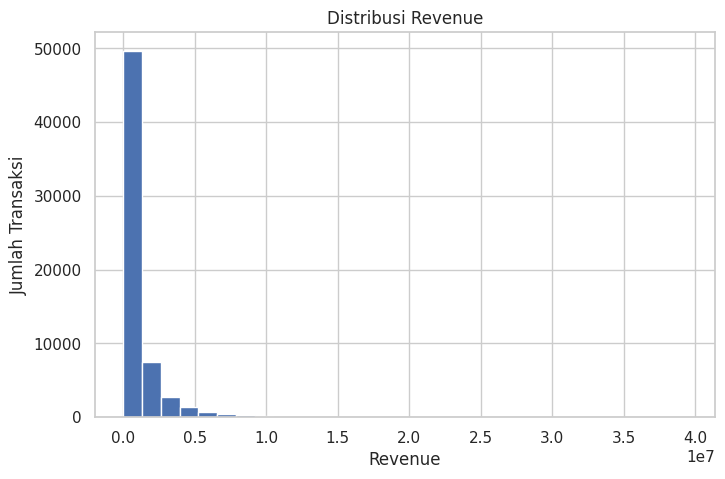

In [7]:
plt.figure(figsize=(8,5))

plt.hist(transaction_clean['Revenue'], bins=30)

plt.title("Distribusi Revenue")
plt.xlabel("Revenue")
plt.ylabel("Jumlah Transaksi")

plt.show()

**Insight:**

- Mayoritas transaksi menghasilkan revenue rendah hingga menengah.
- Sebagian besar data terkonsentrasi pada nilai revenue kecil.
- Distribusi revenue condong ke kanan (right-skewed) yang menunjukkan ketidakseimbangan distribusi data.
- Hanya sedikit transaksi yang memiliki revenue sangat tinggi.
- Terdapat indikasi outlier pada sisi kanan distribusi.
- Rentang revenue cukup lebar sehingga variasi data tergolong tinggi.

### **Distribusi Units Sold**

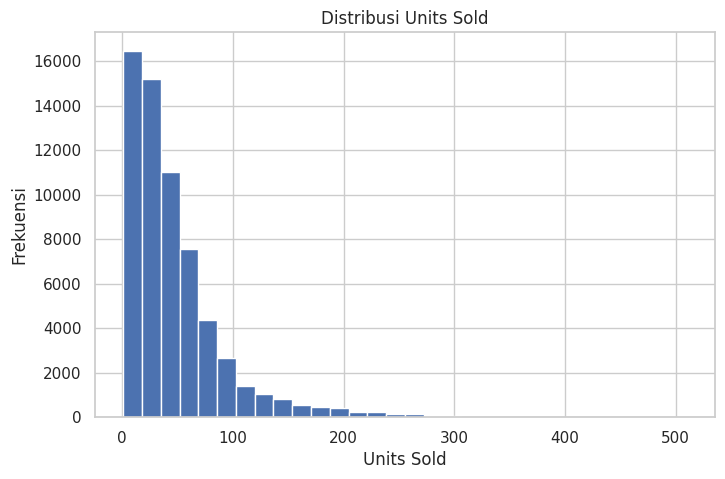

In [8]:
plt.figure(figsize=(8,5))

plt.hist(transaction_clean['Units_Sold'], bins=30)

plt.title("Distribusi Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frekuensi")

plt.show()

**Insight:**

- Mayoritas transaksi memiliki jumlah unit terjual yang rendah.
- Distribusi units sold condong ke kanan (right-skewed) sehingga sebagian besar transaksi berada pada rentang unit kecil hingga menengah.
- Hanya sedikit transaksi dengan jumlah unit terjual sangat besar.
- Terdapat indikasi outlier pada sisi kanan distribusi yang menunjukkan kemungkinan pembelian dalam jumlah besar.
- Pola distribusi menunjukkan transaksi dengan volume kecil lebih sering terjadi dibanding transaksi volume tinggi.
- Variasi jumlah unit terjual cukup tinggi antar transaksi.

### **Distribusi Category**

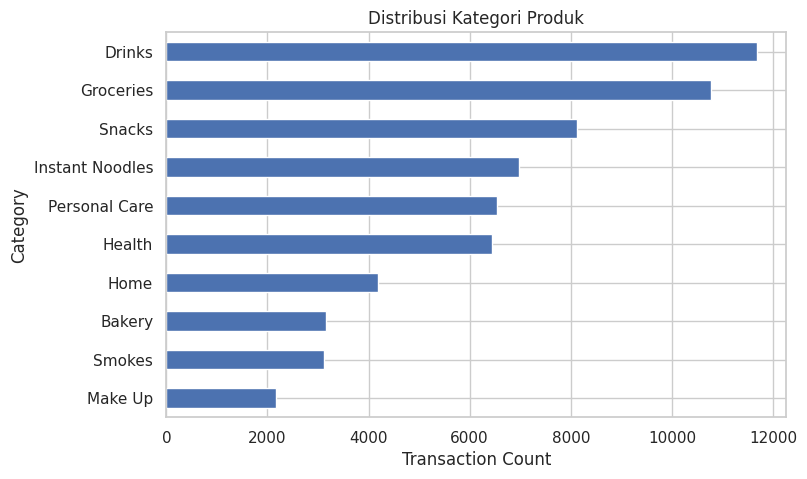

In [9]:
plt.figure(figsize=(8,5))

transaction_clean['Category'].value_counts().plot(kind='barh')

plt.title("Distribusi Kategori Produk")
plt.xlabel("Transaction Count")
plt.ylabel("Category")

plt.gca().invert_yaxis()
plt.show()

**Insight:**

- Kategori Drinks merupakan kategori dengan jumlah transaksi tertinggi dibanding kategori lainnya.
- Groceries dan Snacks juga memiliki frekuensi transaksi yang tinggi sehingga menjadi kategori yang paling dominan setelah Drinks.
- Kategori Make Up memiliki jumlah transaksi paling rendah dalam distribusi data.
- Produk kebutuhan sehari-hari seperti minuman, bahan pokok, dan makanan ringan mendominasi transaksi penjualan.
- Selisih jumlah transaksi antar kategori menunjukkan adanya perbedaan tingkat permintaan produk.
- Kategori seperti Bakery, Smokes, dan Make Up memiliki kontribusi transaksi yang relatif kecil dibanding kategori utama.
- Pola distribusi mengindikasikan bahwa konsumen lebih sering membeli produk kebutuhan rutin dibanding produk sekunder atau pelengkap.

# **VISUALIZATION & EXPLANATORY ANALYSIS**

### **Q1 : Produk apa yang paling laku?**

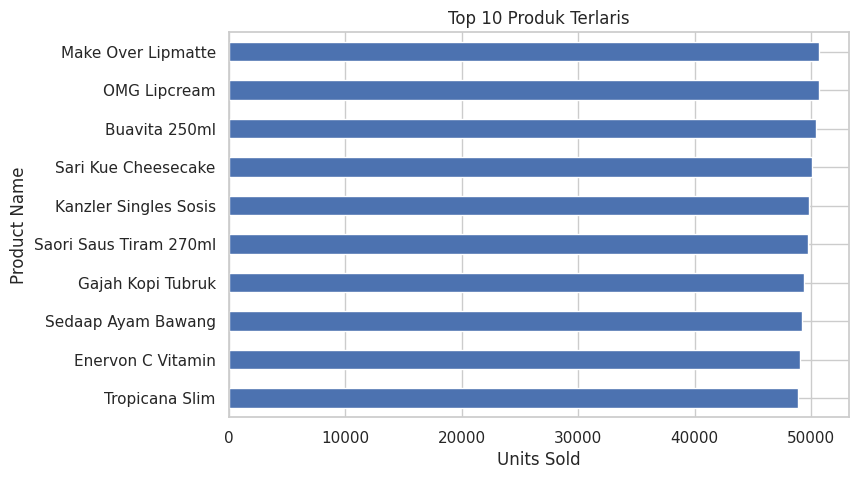

In [10]:
top_units = transaction_clean.groupby('Product_Name')['Units_Sold'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

top_units.plot(kind='barh')

plt.title("Top 10 Produk Terlaris")
plt.xlabel("Units Sold")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()
plt.show()

**Insight:**

- Make Over Lipmatte menjadi produk dengan jumlah unit terjual tertinggi.
- OMG Lip Cream dan Buavita 250ml juga termasuk dalam daftar produk dengan penjualan tertinggi.
- Selisih jumlah penjualan antar produk pada Top 10 relatif kecil, mengindikasikan persaingan penjualan yang cukup kompetitif.
- Produk pada Top 10 berasal dari beberapa kategori seperti makanan, minuman, dan produk perawatan diri.
- Produk seperti kopi, minuman kemasan, dan kosmetik mengindikasikan tingkat permintaan konsumen yang relatif tinggi berdasarkan jumlah unit terjual.
- Pola ini menunjukkan bahwa beberapa produk tertentu memiliki kontribusi penjualan unit yang lebih tinggi dibanding produk lainnya.

### **Q2: Produk apa yang memiliki revenue terbesar?**

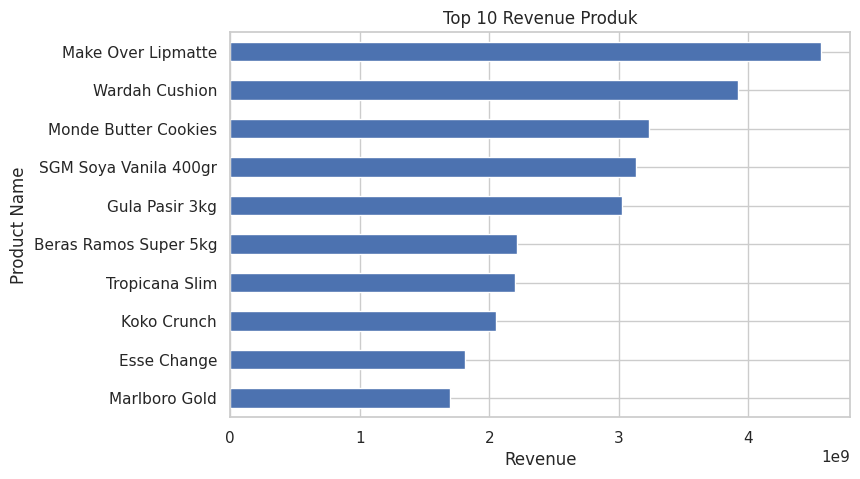

In [11]:
top_rev = transaction_clean.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

top_rev.plot(kind='barh')

plt.title("Top 10 Revenue Produk")
plt.xlabel("Revenue")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()
plt.show()

**Insight:**

- Make Over Lipmatte menjadi produk dengan total revenue tertinggi dibanding produk lainnya.
- Produk kosmetik dan kecantikan seperti Make Over dan Wardah menempati posisi dua teratas, yang mengindikasikan bahwa kategori ini memiliki kontribusi revenue yang relatif tinggi dibanding beberapa kategori lainnya.
- Terdapat perbedaan revenue yang cukup besar antara produk dengan revenue tertinggi dan produk pada peringkat bawah dalam daftar Top 10.
- Produk kebutuhan pokok dan konsumsi harian seperti Gula Pasir 3kg, Beras Ramos Super 5kg, dan SGM Soya Vanila 400gr termasuk ke dalam produk dengan revenue tinggi, yang menunjukkan kontribusi kategori kebutuhan sehari-hari terhadap total revenue.
- Daftar Top 10 revenue ini menunjukkan variasi kategori produk, mulai dari kosmetik, makanan, minuman, kebutuhan pokok, hingga rokok, yang mengindikasikan sumber revenue berasal dari berbagai jenis produk.

### **Q3: Kategori produk apa yang paling dominan?**

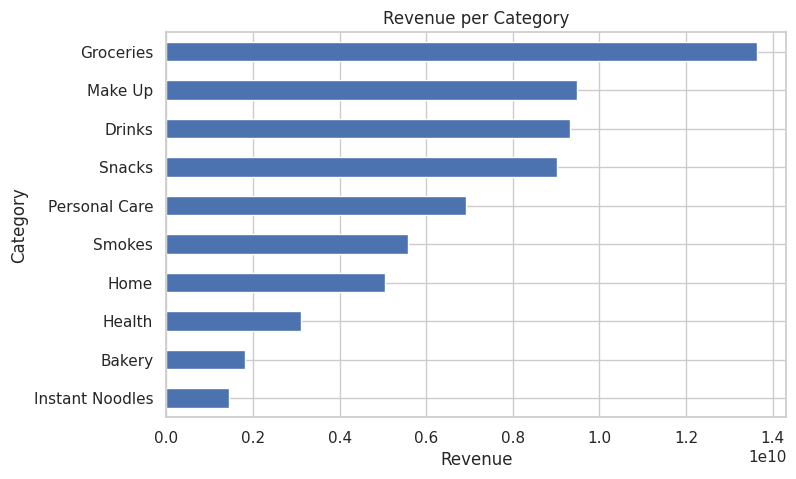

In [12]:
plt.figure(figsize=(8,5))

transaction_clean.groupby('Category', observed=True)['Revenue'].sum().sort_values().plot(kind='barh')

plt.title("Revenue per Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

**Insight:**

- Kategori Groceries menjadi penyumbang revenue tertinggi, menunjukkan kontribusi revenue yang besar.
- Terdapat kesenjangan revenue yang cukup besar antara kategori dengan revenue tinggi seperti Groceries dan kategori dengan revenue lebih rendah seperti Instant Noodles dan Bakery.
- Kategori Groceries, Make Up, dan Drinks mendominasi kategori dengan revenue tertinggi, yang menunjukkan tingginya revenue dari produk kebutuhan sehari-hari maupun perawatan diri.
- Kategori Instant Noodles dan Bakery memiliki revenue yang relatif lebih rendah, yang dapat dipengaruhi oleh faktor seperti harga produk, jumlah transaksi, atau volume penjualan yang lebih rendah dibanding kategori utama.
- Revenue lebih banyak terkonsentrasi pada kategori kebutuhan sehari-hari seperti Groceries, Drinks, dan Snacks dibanding beberapa kategori lainnya.

### **Q4: Bagaimana tren revenue harian?**

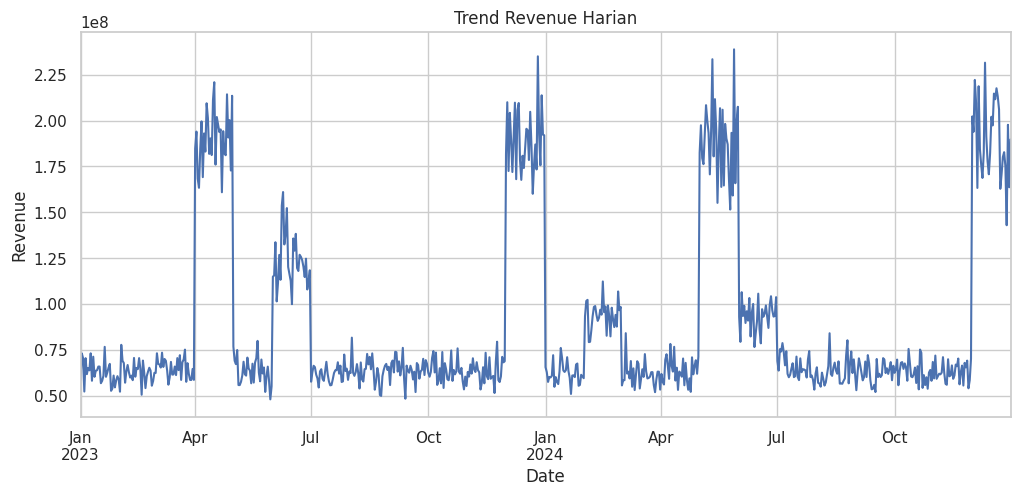

In [13]:
daily_rev = transaction_clean.groupby('Date')['Revenue'].sum()

plt.figure(figsize=(12,5))

daily_rev.plot()

plt.title("Trend Revenue Harian")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

**Insight:**

- Revenue harian menunjukkan pola lonjakan yang muncul berulang pada periode tertentu, di mana pendapatan meningkat signifikan pada waktu-waktu tertentu (seperti awal April, akhir Desember, dan Juni) setelah periode dengan revenue yang relatif stabil.
- Revenue harian menunjukkan fluktuasi yang cukup besar, dengan perubahan dari kisaran sekiar 50 juta oada periode normal menjadi lebih dari 200 juta pada beberapa periode tertentu.
- Titik revenue tertinggi (peak) terlihat pada periode akhir tahun 2023 dan pertengahan 2024, dengan nilai yang melebihi 200 juta per hari.
- Pada sebagian besar periode di tahun 2023, revenue harian berada pada kisaran yang relatif stabil dibanding periode lonjakan, yaitu sekitar 50 juta hingga 75 juta per hari.
- Pola peningkatan revenue pada periode tertentu dapat mengindikasikan kemungkinan adanya faktor musiman, seperti hari raya, periode promo, atau peningkatan permintaan pada waktu tertentu.

### **Q5: Bagaimana hubungan stok in vs penjualan?**

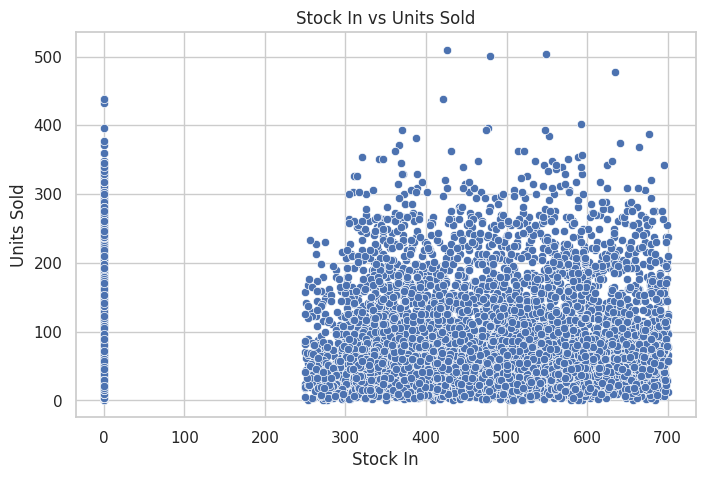

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=transaction_clean, x='Stock_In', y='Units_Sold')

plt.title("Stock In vs Units Sold")
plt.xlabel("Stock In")
plt.ylabel("Units Sold")

plt.show()

**Insight:**

- Persebaran titik pada scatter plot menunjukkan bahwa hubungan antara Stock In dan Units Sold cenderung lemah, karena tidak terlihat pola kenaikan penjualan yang konsisten seiring bertambahnya stok masuk.
- Terdapat kumpulan data pada nilai Stock In = 0 dengan variasi Units Sold yang cukup tinggi. Hal ini menunjukkan bahwa penjualan masih dapat terjadi meskipun tidak ada penambahan stok baru pada periode tersebut, kemungkinan karena produk dijual dari stok persediaan sebelumnya.
- Sebagian besar aktivitas stok masuk terkonsentrasi pada rentang sekitar 250 hingga 700 unit. Namun, volume penjualan mayoritas tetap berada di bawah 250 unit, sehingga menunjukkan bahwa jumlah stok yang tersedia tidak selalu diikuti peningkatan jumlah unit terjual.
- Terdapat indikasi outlier pada beberapa titik yang menunjukkan penjualan yang sangat tinggi hingga menembus lebih dari 500 unit. Menariknya, lonjakan tersebut tidak hanya muncul pada stok masuk tertinggi, tetapi juga pada tingkat stok menengah.
- Kepadatan titik yang cukup tinggi di area penjualan rendah hingga menengah menunjukkan bahwa sebagian besar transaksi memiliki jumlah penjualan pada kisaran tersebut meskipun jumlah stok masuk berbeda-beda.
- Secara keseluruhan, pola persebaran pada grafik menunjukkan bahwa jumlah stok masuk kemungkinan belum cukup menjelaskan variasi penjualan, sehingga faktor lain seperti permintaan pasar, tren produk, promosi, atau perilaku konsumen kemungkinan turut memengaruhi jumlah penjualan.

### **Q6: Bagaimana hubungan stock end vs penjualan?**

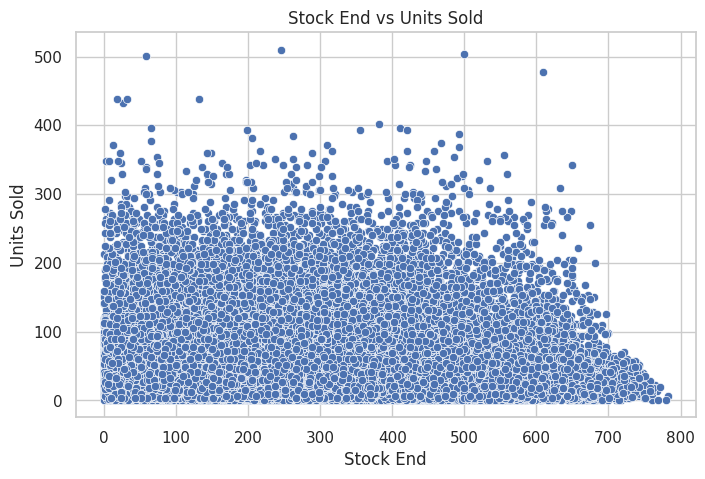

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=transaction_clean, x='Stock_End', y='Units_Sold')

plt.title("Stock End vs Units Sold")
plt.xlabel("Stock End")
plt.ylabel("Units Sold")

plt.show()

**Insight:**

- Scatter plot menunjukkan bahwa hubungan antara Stock End dengan Units Sold cenderung tidak memiliki pola linear yang kuat, karena titik data terlihat menyebar dan tidak menunjukkan arah tren tertentu.
- Penjualan dengan volume tinggi (lebih dari 400 unit) lebih banyak terjadi ketika stok akhir berada pada tingkat rendah hingga menengah. Hal ini mengindikasikan bahwa penjualan tinggi berkaitan dengan berkurangnya stok yang tersisa.
- Pada area kanan bawah grafik terlihat banyak titik dengan Stock End tinggi (mendekati 700–800 unit) namun Units Sold sangat rendah. Kondisi ini mengindikasikan adanya kondisi slow-moving stock atau stok berlebih (overload).
- Mayoritas data terkonsentrasi pada Units Sold di bawah 250 unit dengan Stock End di bawah 600 unit, yang menunjukkan bahwa sebagian besar transaksi berada pada rentang penjualan yang rendah hingga menengah dengan jumlah stok akhir yang tidak terlalu tinggi.
- Pola berbentuk segitiga pada persebaran data menunjukkan bahwa transaksi dengan Stock End tinggi cenderung memiliki Units Sold yang lebih rendah, sementara penjualan tinggi lebih sering muncul pada tingkat stok akhir rendah hingga menengah.
- Terdapat indikasi keberadaan produk dengan Stock End tinggi dan Units Sold rendah, yang berpotensi adanya produk yang mengalami slow-moving atau kondisi stok berlebih (overstock).
- Secara keseluruhan, pola persebaran data mengindikasikan bahwa tingkat Units Sold kemungkinan berkaitan dengan bagaimana stok bergerak atau terjual pada periode tertentu, bukan hanya jumlah stok yang tersisa di akhir periode.

# **ANALISIS LANJUTAN**

### **Pareto Analysis**

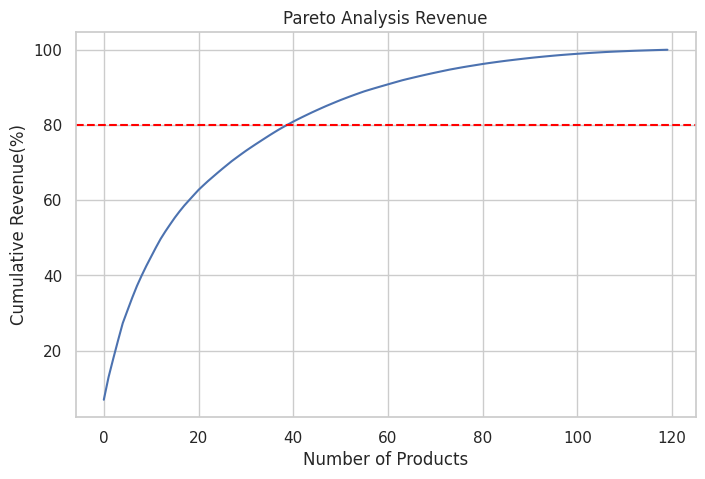

In [16]:
prod_rev = transaction_clean.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

cum = prod_rev.cumsum() / prod_rev.sum() * 100

plt.plot(cum.values)
plt.axhline(80, color='red', linestyle='--')

plt.title("Pareto Analysis Revenue")
plt.xlabel("Number of Products")
plt.ylabel("Cumulative Revenue(%)")

plt.show()

**Insight:**

- Sebanyak 80% total revenue dihasilkan oleh sekitar 40 produk teratas, ditunjukkan oleh titik perpotongan kurva biru dengan garis putus-putus merah pada sumbu horizontal.
- Grafik menunjukkan adanya konsentrasi revenue pada sebagian produk, di mana sekitar 40 dari 120 produk menyumbang sebagian besar total pendapatan. Hal ini menunjukkan pola yang menyerupai Prinsip Pareto.
- Kurva yang melandai secara signifikan setelah melewati sekitar 40 produk menunjukkan bahwa sebagian besar revenue telah terkonsentrasi pada kelompok produk teratas, sementara produk berikutnya memberikan tambahan kontribusi yang relatif lebih rendah terhadap total revenue.
-  Pola kontribusi revenue pada bagian akhir kurva menunjukkan adanya kelompok produk dengan kontribusi relatif kecil terhadap total revenue, yang berpotensi menjadi fokus analisis lebih lanjut dalam optimalisasi portofolio produk guna mengurangi biaya operasional atau inventori pada produk yang memberikan hasil minimal terhadap total revenue.

### **Fast vs Slow Moving Product**

In [17]:
product_analysis = transaction_clean.groupby('Product_Name').agg({
    'Units_Sold':'sum',
    'Stock_In':'sum',
    'Stock_End':'sum'
})

product_analysis['Turnover'] = product_analysis['Units_Sold'] / product_analysis['Stock_In']

fast_moving = product_analysis.sort_values('Turnover', ascending=False).head()
slow_moving = product_analysis.sort_values('Turnover', ascending=True).head()

print("Fast Moving Products")
display(fast_moving.reset_index())

print("\nSlow Moving Products")
display(slow_moving.reset_index())

Fast Moving Products


,Product_Name,Units_Sold,Stock_In,Stock_End,Turnover
0,Stella Spray 400ml,45450,45462,213015,0.999736
1,Monde Butter Cookies,35984,36012,210358,0.999222
2,Poci Teh Celup,48488,48528,208406,0.999176
3,Beras Ramos Super 5kg,34148,34189,196992,0.998801
4,Fanta 1L,6601,6612,93784,0.998336



Slow Moving Products


,Product_Name,Units_Sold,Stock_In,Stock_End,Turnover
0,Dettol Body Wash 200ml,6000,6666,117792,0.900090
1,Mama Lemon Sabun Cuci Piring,6208,6826,97947,0.909464
2,Sedaap Kecap Manis 550ml,6314,6871,104352,0.918935
3,Indomie Goreng,7490,8127,97478,0.921619
4,Teh Pucuk Harum 350ml,6345,6855,98619,0.925602


**Insight:**

- Produk pada kelompok fast-moving seperti Stella Spray 400ml, Monde Butter Cookies, dan Poci Teh Celup, memiliki nilai turnover mendekati 1. Hal ini menunjukkan bahwa jumlah Units Sold hampir setara dengan Stock In, sehingga produk ini memiliki tingkat perputaran stok yang sangat tinggi.
- Sebaliknya, produk pada kelompok slow-moving seperti Dettol Body Wash 200ml, Mama Lemon Sabun Cuci Piring, dan Sedaap Kecap Manis 550ml memiliki turnover yang relatif lebih rendah dibanding produk lainnya, meskipun nilainya masih berada di kisaran 0.90–0.93.
- Selisih antara Units Sold dan Stock In pada kelompok fast-moving terlihat relatif lebih kecil dibanding kelompok slow-moving, yang menunjukkan adanya perbedaan tingkat perputaran stok antarproduk.
- Produk kebutuhan sehari-hari seperti makanan, minuman, dan kebutuhan rumah tangga muncul pada kedua kelompok, yang menunjukkan bahwa tingkat turnover dapat bervariasi meskipun berasal dari kategori yang sama-sama dikonsumsi secara rutin.
- Secara keseluruhan, terdapat variasi tingkat turnover antarproduk, meskipun sebagian besar produk masih menunjukkan nilai turnover yang relatif tinggi.